In [1]:
!pip install pyne2001
!pip install pyvo
!pip install extinction
!pip install dustmaps
!pip install linetools
!pip install --ignore-installed --no-cache-dir astro-datalab --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyne2001: filename=pyne2001-0.1.3-py3-none-any.whl size=93704 sha256=9896b68d18d92b543e28525b2fc371c7a1ac2afa61a2e4e791b2b460ac3f8c04
  Stored in directory: /tmp/pip-ephem-wheel-cache-e97bltjh/wheels/6b/a2/68/51e7e7b0a68b70e79a4f4479b9a81e95cc9a74daad2390aa53
Successfully built pyne2001
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 10.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.6/750.6 kB 14.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 67.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 8.1 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 70.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 8.2 MB/s eta 0:00:00


In [3]:
from glob import glob
import numpy as np

import pandas as pd

from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u


import glob

import astroquery

from astroquery.simbad import Simbad

import astropy.units as u
import pyne2001
import astropy.coordinates as coord
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

In [5]:
path_runs = glob('/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/*/*candidates.xlsx')

path_runs
import pandas as pd
for pr in path_runs:
    cands = pd.read_excel(pr)
    if (cands['P_Ox'] > 0.9).any():
        print(pr)
        print(cands[0:2])

/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/FRB20231011A/FRB20231011A_PATH_candidates.xlsx
          ra        dec  ang_size        mag                  ID        sep   
0  18.241706  41.748995   7.93588  17.923700  158090182417819186   1.668334  \
1  18.241790  41.766536   3.80639  19.299601  158120182416650397  62.804431   

        P_O          p_xO          P_Ox      P_Ux      survey  
0  0.146858  1.923018e-03  9.913327e-01  0.008667  Pan-STARRS  
1  0.032120  2.770109e-10  3.123303e-08  0.008667  Pan-STARRS  



KeyboardInterrupt



In [55]:

def get_ne2001(c_icrs,get_scatt = True):
    dm_ne2001 = np.zeros(len(c_icrs))
    tau600_ne2001 = np.zeros(len(c_icrs))

    for ii,(gl,gb) in enumerate(zip(c_icrs.galactic.l,c_icrs.galactic.b)):
        ne2001_pred = pyne2001.get_dm_full(gl.value,gb.value,dist_kpc = 100.0)
        #print(f"dist: {ne2001_pred['DIST']}")
        dm_ne2001[ii] = ne2001_pred['DM']
        tau600_ne2001[ii] = ne2001_pred['TAU'] * (1/0.6)**4
    if get_scatt:
        return dm_ne2001,tau600_ne2001
    else:
        return dm_ne2001
def calculate_halo_dm_yt20(l, b):
    coeffs = np.array(
        [
            [250.12, -871.06, 1877.5, -2553.0, 2181.3, -1127.5, 321.72, -38.905],
            [-154.82, 783.43, -1593.9, 1727.6, -1046.5, 332.09, -42.815, 0],
            [-116.72, -76.815, 428.49, -419.00, 174.60, -27.610, 0, 0],
            [216.67, -193.30, 12.234, 32.145, -8.3602, 0, 0, 0],
            [-129.95, 103.80, -22.800, 0.44171, 0, 0, 0, 0],
            [39.652, -21.398, 2.7694, 0, 0, 0, 0, 0],
            [-6.1926, 1.6162, 0, 0, 0, 0, 0, 0],
            [0.39346, 0, 0, 0, 0, 0, 0, 0],
        ]
    )
    l_absolute = np.abs(np.deg2rad(l))
    b_absolute = np.abs(np.deg2rad(b))
    DM_halo = 0
    for ii in range(8):
        for jj in range(8):
            DM_halo += coeffs[ii, jj] * l_absolute ** ii * b_absolute ** jj
    return DM_halo # u.pc / u.cm ** 3

In [56]:
import pandas

# Make DSA spreadsheet 


In [86]:
dsa_110_frbs = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/dsa_110_published.csv',
    names= ['Internal Name','MJD', 'DM','Width','SNR','ra','dec','poserr','Name','Redshift'],
                           skiprows = 1)

coord_dsa = coord.SkyCoord(dsa_110_frbs['ra'].values,dsa_110_frbs['dec'].values,unit = 'deg')

import pyne2001

get_ne2001(coord_dsa)

dsa_110_frbs

# compare new PATH run 020240916

In [54]:
final = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts.csv',names = [
    'chime_event_id','TNS', 
    'DM','ra','dec',
    'wfall','Note','RM','pol_fraction',
    'Stokes_parameters_corrected',
    'fdf_clean', 'burst_profile', 
    'pol_pipeline_note','tau_scatt_ms',
    'tau_scatt_unc_ms', 'tau600_ne2001', 
    'fitburst_plot', 'fitburst_type', 
    'fitburst_note', 'P_Ox', 'hg_notes', 
    'redshift', 'simbad_link', 'redshift_info','hg_id','redshift_err',],
                   skiprows=1)
final.set_index('TNS',inplace=True)

path_runs = glob('/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/*/*candidates.xlsx')

path_runs
import pandas as pd
for pr in path_runs:
    tns = pr.split('/')[-2][3:]
    cands = pd.read_excel(pr)
    print(tns)
    print('new run:',cands[0:1][['P_Ox']].values,int(cands[0:1][['ID']].values))
    try:
        print('old galaxy:',final.loc[tns][['P_Ox']],int(final.loc[tns]['hg_id'].split(' ')[1]))
    except KeyError:
        print('old galaxy: not in final.csv')
    except AttributeError:
        if np.isnan(final.loc[tns]['hg_id']):
            print('no old ID')

# Load in final ellipse catalog

In [203]:
final = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/kko_ellipse_cat.csv',
names = ['name','chime_event_id', 'ra_frb','dec_frb','b_err','a_err','theta','tags','frb_survey','DM','include','locnote', 'hgnote', 'desi_cutout'],
    skiprows=1)
final.set_index('chime_event_id',inplace=True)
final = final[final['include'] == 'yes']

# Add galactic DM & tau

In [204]:
from astropy.coordinates import SkyCoord

c_icrs = SkyCoord(ra=final['ra_frb'].values,
                  dec=final['dec_frb'].values,unit = 'deg',frame = 'icrs') # baseband position

dm_ne2001, tau600_ne2001 = get_ne2001(c_icrs,get_scatt = True)
dm_yt20 = calculate_halo_dm_yt20(l = c_icrs.galactic.l.deg, b= c_icrs.galactic.b.deg)

final.insert(loc = 5, column = 'DM_NE2001',value = dm_ne2001,allow_duplicates = False)
final['tau_NE2001_600'] = tau600_ne2001
final.insert(loc = 5, column = 'DM_YT20',value = dm_yt20,allow_duplicates = False)
final.insert(loc = 5, column = 'gal_l', value = c_icrs.galactic.l.deg)
final.insert(loc = 5, column = 'gal_b', value = c_icrs.galactic.b.deg)

In [205]:
final

,name,ra_frb,dec_frb,b_err,a_err,gal_b,gal_l,DM_YT20,DM_NE2001,theta,tags,frb_survey,DM,include,locnote,hgnote,desi_cutout,tau_NE2001_600
chime_event_id,,,,,,,,,,,,,,,,,,
335002503,FRB20231110B,171.616790,35.806703,0.000556,0.008815,69.969260,182.009479,29.859593,20.5907,9.067814,CHIME-KKO,CHIME/FRB,726.660584,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.000318
348570237,FRB20231230B,355.772818,78.089194,0.000556,0.004585,15.699410,119.320440,38.051108,90.1400,6.537953,CHIME-KKO,CHIME/FRB,476.757263,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.007540
325140573,FRB20231005A,246.028004,35.448712,0.000556,0.003164,44.353154,57.165296,39.135917,33.4704,10.482417,CHIME-KKO,CHIME/FRB,188.842789,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.000931
331641308,FRB20231028B,151.361850,54.378893,0.000556,0.003125,49.367116,159.273629,29.989064,37.0543,9.096674,CHIME-KKO,CHIME/FRB,333.610000,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.000829
326033351,FRB20231009A,211.756891,17.211412,0.000556,0.014189,69.923732,7.254291,35.536848,22.3789,8.043601,CHIME-KKO,CHIME/FRB,391.029907,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.000391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337199498,FRB20231118B,213.679783,72.350210,0.000556,0.004659,43.372715,114.406001,32.079456,37.4434,4.141294,CHIME-KKO,CHIME/FRB,317.433807,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.000954
325442526,FRB20231007B,307.531693,72.892348,0.000556,0.003244,19.057901,106.503645,39.034962,73.4989,7.292682,CHIME-KKO,CHIME/FRB,202.500000,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.004735
325287323,FRB20231006B\n,109.619968,84.776136,0.000556,0.004456,27.621518,128.788831,33.103154,54.8405,-1.920917,CHIME-KKO,CHIME/FRB,1252.300000,yes,NaN,NaN,https://www.legacysurvey.org/viewer%20dr9%20ph...,0.002246


# Add PATH results

In [206]:
PATH_TO_PATH = '/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/'
path_runs = glob('/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/*/*candidates.xlsx')


In [207]:
path_runs.sort()

In [208]:
import os

In [209]:
import json

In [263]:
cands

,ra,dec,ang_size,mag,ID,sep,P_O,p_xO,P_Ox,P_Ux,z_phot_median,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,z_spec,survey
0,325.605406,2.374374,1.541843,20.152410,10995477648510729,32.133274,0.000412,0.000537,0.503481,0.165274,0.291318,0.254843,0.339635,0.230044,0.419534,-99.0,DECaL
1,325.605332,2.377853,0.973593,21.617760,10995479158460138,44.636474,0.000099,0.000257,0.058166,0.165274,0.400046,0.318272,0.518723,0.247371,0.607017,-99.0,DECaL
2,325.605437,2.372513,0.381941,22.846062,10995477648510732,25.453727,0.000033,0.000720,0.054289,0.165274,0.830985,0.752892,0.982239,0.680728,1.198993,-99.0,DECaL
3,325.599369,2.317448,1.741226,20.279985,10995477648510512,174.000032,0.000362,0.000040,0.032743,0.165274,0.284814,0.101848,0.562875,0.065941,0.724720,-99.0,DECaL
4,325.606174,2.366354,0.584403,22.463566,10995477648510764,5.498352,0.000046,0.000259,0.027239,0.165274,0.480302,0.414029,0.535910,0.329549,0.582253,-99.0,DECaL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10131,325.519110,2.387045,0.291870,24.920155,10995479158457071,318.335742,0.000006,0.000000,0.000000,0.165274,1.053915,0.868786,1.239359,0.488286,1.698050,-99.0,DECaL
10132,325.517674,2.393542,0.462183,24.204203,10995479158457026,329.748140,0.000011,0.000000,0.000000,0.165274,0.958068,0.527869,1.414504,0.302378,2.457447,-99.0,DECaL
10133,325.512128,2.396002,0.541253,23.917429,10995479158456830,351.460113,0.000014,0.000000,0.000000,0.165274,0.752632,0.622061,0.899944,0.483468,1.087749,-99.0,DECaL
10134,325.510779,2.395854,0.587699,23.551476,10995479158456770,355.905977,0.000018,0.000000,0.000000,0.165274,1.020722,0.880739,1.178825,0.571725,1.334524,-99.0,DECaL


In [264]:
for pr in path_runs:
    tns = pr.split('/')[-2][3:]
    path_input = glob(os.path.join(PATH_TO_PATH,'FRB'+tns,'*input.json'))[0]
    xlsx_input = glob(os.path.join(PATH_TO_PATH,'FRB'+tns,'*candidates.xlsx'))[0]
    cands = pd.read_excel(xlsx_input)
    where = np.where('FRB' + tns == final['name'])
    if len(where[0]) > 0:
        index = final.index[where[0][0]]  
        print(f'FRB{tns}: {index}')
        final.loc[index,'primary_id'] = f"{cands.iloc[0]['survey']} {cands.iloc[0]['ID']}"
        for key in ['ra','dec','P_Ox','z_phot_median','z_phot_l95','z_phot_u95','z_spec','mag']:
            try:
                final.loc[index,f'primary_{key}'] = cands.iloc[0][key]
            except KeyError:
                final.loc[index,f'primary_{key}'] = -1
        for key in ['ra','dec','P_Ox','z_phot_median','z_phot_l95','z_phot_u95','z_spec']:
            try:
                final.loc[index,f'secondary_{key}'] = cands.iloc[1][key]
            except KeyError:
                final.loc[index,f'secondary_{key}'] = -1
                print(index,tns,'had no',key)

FRB20221209A: 254837189
FRB20230203A: 268786306
FRB20230222B: 272367619
FRB20230311A: 275629567
FRB20230314A: 276387136
FRB20230317A: 277059004
FRB20230409A: 281936786
FRB20230410A: 282159121
FRB20230411A: 282352003
FRB20230414A: 282988614
282988614 20230414A had no z_phot_median
282988614 20230414A had no z_phot_l95
282988614 20230414A had no z_phot_u95
282988614 20230414A had no z_spec
FRB20230414B: 283032006
283032006 20230414B had no z_phot_median
283032006 20230414B had no z_phot_l95
283032006 20230414B had no z_phot_u95
283032006 20230414B had no z_spec
FRB20230616A: 296843842
FRB20230702A: 300895079
FRB20230703A: 300938875
FRB20230720A: 304166930
FRB20230730A: 306528286
306528286 20230730A had no z_phot_median
306528286 20230730A had no z_phot_l95
306528286 20230730A had no z_phot_u95
306528286 20230730A had no z_spec
FRB20230802A: 307424887
FRB20230805A: 308358106
308358106 20230805A had no z_phot_median
308358106 20230805A had no z_phot_l95
308358106 20230805A had no z_phot_u9

In [267]:
final[['name','primary_P_Ox','primary_z_spec','primary_mag']][final['primary_P_Ox'] > 0.9]

,name,primary_P_Ox,primary_z_spec,primary_mag
chime_event_id,,,,
325140573,FRB20231005A,0.984624,0.000000,17.819340
342256558,FRB20231204A,0.976179,0.000000,15.397451
339589360,FRB20231128A,0.984675,0.000000,17.306005
347082860,FRB20231223C,0.953420,0.105909,16.498093
330976597,FRB20231025B,0.925295,0.000000,20.929941
330838705,FRB20231025C,0.947554,-1.000000,20.414000
328261629,FRB20231017A,0.918165,-1.000000,20.364700
321977347,FRB20230926A,0.995847,0.000000,15.458912
338403209,FRB20231123A,0.955910,-1.000000,18.294300


In [406]:
fluxfluence = {306528286 : (43.88,4.41,37.07,3.82),
272367619 : (91.35,9.14,37.55,3.80),
272350056 : (4.47,0.47,129.17,12.97),
275629567 : (9.47,0.97,12.18,1.29),
300938875 : (9.36,0.97,8.45,0.93),
268786306 : (6.15,0.65,173.03,17.40),
326456063 : (129.53,12.96,58.32,5.86),
341758878 : (31.10,3.14,33.82,3.47),
341477821 : (35.13,3.53,10.83,1.15),
338403209 : (52.66,5.31,56.84,5.85),
330976597 : (5.97,0.64,5.23,0.61),
325634353 : (3.43,0.60,14.55,1.82),
321375070 : (23.33,2.35,34.00,3.45),
325140573 : (221.19,22.13,60.02,6.05),
339589360 : (2.77,0.32,67.68,6.87),
342256558 : (4.66,0.55,25.53,2.71),
347082860 : (68.07,6.81,287.17,28.75),
348537586 : (6.59,1.05,37.10,4.37),
313479875 : (50.74,5.11,338.89,34.03),
300895079 : (29.75,3.04,52.60,5.40),
281936786 : (28.35,2.96,72.72,7.56),
330838705 : (16.58,1.68,3.93,0.44),
328261629 : (33.60,3.37,8.19,0.86),
321977347 : (26.78,2.78,28.41,3.08),
342760050 : (9.88,1.13,179.43,18.23),
325442526 : (52.87,5.30,138.87,13.93),
}

In [407]:
for evid,row in final.iterrows():
    if evid in fluxfluence.keys():
        final.at[evid,'flux'] = fluxfluence[evid][0]
        final.at[evid,'flux_err'] = fluxfluence[evid][1]
        final.at[evid,'fluence'] = fluxfluence[evid][2]
        final.at[evid,'fluence_err'] = fluxfluence[evid][3]

In [408]:
final.index[np.isnan(final['flux']) * (final['primary_P_Ox'] > 0.9)]

Index([], dtype='int64', name='chime_event_id')

In [400]:
print((final[~np.isnan(final['flux']) * (final['primary_P_Ox'] < 0.9)]["primary_P_Ox"]).to_string())

chime_event_id
321375070    0.747105
275629567    0.773594
281936786    0.683662
313479875    0.000011
300895079    0.538390


# Approximate optical selection function

In [66]:
gal_lf = pd.read_csv('/arc/home/calvin/FRB/frb/data/Galaxies/galLF_vs_z.txt',sep='\t')

In [67]:
gal_lf

,z,m_r(L*),m_r(0.1L*),m_r(0.01L*)
0,0.020000,14.3354,16.8354,19.3354
1,0.050000,15.3354,17.8354,20.3354
2,0.089899,17.3708,19.8708,22.3708
3,0.129798,18.3882,20.8882,23.3882
4,0.169697,18.9821,21.4821,23.9821
...,...,...,...,...
96,3.840400,25.2699,27.7699,30.2699
97,3.880300,25.2877,27.7877,30.2877
98,3.920200,25.3052,27.8052,30.3052
99,3.960100,25.3226,27.8226,30.3226


In [68]:
def max_z_attainable(source_table,survey_depth,sigmas = 5,
                     dwarf_mag = -17, # R1 r' band from Tendulkar 2017, 
                     subtract_ne2001 = 0.8, 
                     subtract_halo = 30,
                     verbose = False
                     ):
        """Maximum redshift out to which we are complete to R1 hosts."""
    def dm_mw(coords):
        dm_mw_arr = []
        for c_icrs in coords:
            gl = c_icrs.galactic.l.value
            gb = c_icrs.galactic.b.value
            #print(f'For ra,dec = {c_icrs.ra.deg,c_icrs.dec.deg} <--> gl,gb={gl,gb}:')
            ne2001_pred = pyne2001.get_dm_full(gl,gb,dist_kpc = 100.0)
            #print(f"dist: {ne2001_pred['DIST']}")
            #print(f"dm  : {ne2001_pred['DM']}")
            #print(f"tau : {ne2001_pred['TAU']} ms @ 1 GHz")
            #print(f"tau : {ne2001_pred['TAU'] * (1000 / 600)**4.4} ms @ 0.6 GHz")
            dm_mw_arr.append(ne2001_pred['DM'])
        return np.array(dm_mw_arr)

    def max_z_from_dm(sources,dm_tots,factor = 1,halo = 0):
        assert len(sources) == len(dm_tots), "Wrong number of sources or DMs"
        dm_mws = np.array(dm_mw(sources)) * factor # allow 20% error on NE2001
        dm_sub = np.array(dm_tots) - dm_mws
        zmax = dm_sub / 985
        print(f'Extragalactic DM of {dm_sub} implies zmax = {zmax}')
        return zmax

    sources = coord.SkyCoord(source_table['ra'],source_table['dec'],unit = 'deg',frame = 'icrs')
    dm_tots = source_table['DM']
    n_src = len(sources)
    sfd = SFDQuery()
    e_b_minus_v = sfd(sources)
    r_v = 3.1
    a_v = r_v * e_b_minus_v
    # in SDSS R-band, as used by Shriharsh, the passband is centered at 0.625um -> x = 1.600. 
    # We want A(R), and A(lambda) / A(V) is provided using Table 3 from the OG Cardelli 1989 paper.
    # https://articles.adsabs.harvard.edu/pdf/1989ApJ...345..245C
    a_r_over_a_v = 1 + (0.751 - 1) * (1.6 - 1.82) / (1.43 - 1.82) # linear interpolation: y - y0 = (x - x0) * (y1 - y0) / (x1 - x0)
    a_r = a_r_over_a_v * a_v
    lum_dist_pc = 10 * 10**((survey_depth - dwarf_mag - a_r) / 5) # luminosity distances in parsecs
    redshift_grid = np.linspace(0,1,num = 300)
    from astropy.cosmology import WMAP9
    lum_dists = WMAP9.luminosity_distance(redshift_grid).to(u.pc).value
    if verbose: print(lum_dist_pc)
    z_limits = []
    v_limits = []
    z_maxs = max_z_from_dm(sources,dm_tots,factor = subtract_ne2001, halo = subtract_halo)
    v_maxs = WMAP9.comoving_volume(z_maxs).to(u.Mpc**3).value
    for ii in range(n_src):
        idx_closest = np.argmin(np.abs(lum_dists - lum_dist_pc[ii]))
        z_limit = redshift_grid[idx_closest]
        if verbose: print(f'Limiting distance is {lum_dists[idx_closest] / 1e9:.3f} Gpc (z={z_limit})')
        if verbose: print(f'For a survey down to m_r = {survey_depth:.0f}, M_r = {dwarf_mag:.0f} host would show up for z < {z_limit}.')
        v_limit = WMAP9.comoving_volume(z_limit).to(u.Mpc**3).value
        z_limits.append(z_limit)
        v_limits.append(v_limit)
    return np.array(z_limits),z_maxs,np.array(v_limits),v_maxs


In [69]:
%matplotlib inline

In [70]:
from astropy import units as u

In [72]:
import matplotlib.pyplot as plt

In [115]:
from dustmaps.sfd import SFDQuery
import dustmaps.sfd
dustmaps.sfd.fetch()

zl,zm,vl,vm = max_z_attainable(final,survey_depth = 23,sigmas = 5,dwarf_mag = -17,subtract_ne2001 = 1.0,subtract_halo = 30)

 63.2 MiB of 64.0 MiB |  30.4 MiB/s |################## |  98% | ETA:   0:00:000

 62.4 MiB of 64.0 MiB |  27.8 MiB/s |################## |  97% | ETA:   0:00:000

Extragalactic DM of [227.3565 160.0188 571.8588 272.5104 264.3449 383.7878 115.9431 294.3756
  99.4479 212.3514 320.0312  95.0623 890.0733 155.3296 307.3937 192.1713
 131.6741  69.8444 322.0618 549.7676 369.725 ] implies zmax = [0.23081878 0.16245563 0.58056731 0.2766603  0.26837046 0.38963228
 0.11770873 0.29885848 0.10096234 0.21558518 0.32490477 0.09650995
 0.90362772 0.15769503 0.31207482 0.19509777 0.13367929 0.07090802
 0.32696629 0.5581397  0.37535533]


In [118]:
final['max_z_of_R1_host_mr=23'] = zl
final['max_z_from_DM'] = zl

In [125]:
final.to_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')

# Add HG coordinates

In [213]:
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

In [214]:
csv = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')
csv.set_index('chime_event_id',inplace=True)

In [215]:
final.index

Index([335002503, 348570237, 325140573, 331641308, 326033351, 347265274,
       308358106, 342256558, 341979347, 344693725, 324962446, 348285021,
       339589360, 348687097, 325515646, 347082860, 343537552, 330976597,
       330838705, 339069867, 322840327, 328261629, 333031657, 347027446,
       321977347, 347261948, 332593291, 333356311, 319829796, 338403209,
       343770778, 347052803, 328879027, 343712196, 347465543, 347433921,
       329033047, 327479591, 321375070, 348537586, 337105685, 334942484,
       341758878, 329248428, 328495927, 341477821, 331618070, 347419602,
       317888392, 326456063, 283032006, 275629567, 318361859, 281936786,
       282988614, 313479875, 276387136, 282352003, 307424887, 300938875,
       306528286, 268786306, 272350056, 300895079, 254837189, 296843842,
       304166930, 282159121, 296798120, 277059004, 272367619, 358105468,
       346002524, 347603667, 342760050, 338344597, 339188139, 358233910,
       337199498, 325442526, 325287323, 321637098, 

In [230]:
for key in final.index:
    if final.loc[key]['primary_P_Ox'] > 0.9:
        print('what we have in new file:')
        print(key,final.loc[key]['primary_id'],final.loc[key]['primary_z_spec'])
        if key in csv.index:
            print('present in old file')
            print(csv.loc[key]['hg_id'],csv.loc[key]['redshift'])
            final.at[key,'primary_z_spec'] = np.nanmax([final.loc[key]['primary_z_spec'], csv.loc[key]['redshift']])
            print('Replaced with z=',final.loc[key]['primary_z_spec'])
        else:
            print('no redshift')

what we have in new file:
325140573 DECaL 9907733567310903 0.0
present in old file
nan 0.1032
Replaced with z= 0.1032
what we have in new file:
342256558 DECaL 9907737081938383 0.0
present in old file
nan 0.0639
Replaced with z= 0.0639
what we have in new file:
339589360 DECaL 9907735753852365 0.0
present in old file
nan 0.1078
Replaced with z= 0.1078
what we have in new file:
347082860 DECaL 10995634357144446 0.1059089
present in old file
nan 0.1059
Replaced with z= 0.1059089
what we have in new file:
330976597 DECaL 9907740469102043 0.0
present in old file
DECaL 8797233725048371 0.364
Replaced with z= 0.364
what we have in new file:
330838705 Pan-STARRS 147880719743595797 -1.0
no redshift
what we have in new file:
328261629 Pan-STARRS 151973467535638727 -1.0
no redshift
what we have in new file:
321977347 DECaL 9907735417918096 0.0
no redshift
what we have in new file:
338403209 Pan-STARRS 113360826227259720 -1.0
present in old file
Pan-STARRS 113360826227259720 0.06860938
Replaced w

In [388]:
final.index

Index([335002503, 348570237, 325140573, 331641308, 326033351, 347265274,
       308358106, 342256558, 341979347, 344693725, 324962446, 348285021,
       339589360, 348687097, 325515646, 347082860, 343537552, 330976597,
       330838705, 339069867, 322840327, 328261629, 333031657, 347027446,
       321977347, 347261948, 332593291, 333356311, 319829796, 338403209,
       343770778, 347052803, 328879027, 343712196, 347465543, 347433921,
       329033047, 327479591, 321375070, 348537586, 337105685, 334942484,
       341758878, 329248428, 328495927, 341477821, 331618070, 347419602,
       317888392, 326456063, 283032006, 275629567, 318361859, 281936786,
       282988614, 313479875, 276387136, 282352003, 307424887, 300938875,
       306528286, 268786306, 272350056, 300895079, 254837189, 296843842,
       304166930, 282159121, 296798120, 277059004, 272367619, 358105468,
       346002524, 347603667, 342760050, 338344597, 339188139, 358233910,
       337199498, 325442526, 325287323, 321637098, 

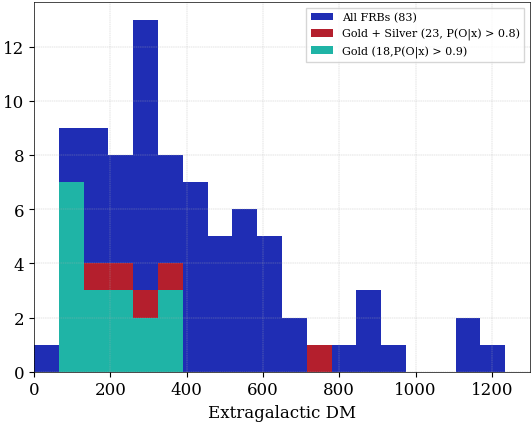

In [410]:
silver_gold = final['primary_P_Ox'] > 0.8
gold = final['primary_P_Ox'] > 0.9

plt.figure()
bins = np.linspace(0,1300,num = 20,endpoint = False)
plt.hist(final['DM'] - final['DM_NE2001'] - final['DM_YT20'],bins = bins,label = f'All FRBs ({len(silver_gold)})')
plt.hist((final['DM'] - final['DM_NE2001'] - final['DM_YT20'])[silver_gold],bins = bins,label = f'Gold + Silver ({np.sum(silver_gold)}, P(O|x) > 0.8)')

plt.hist((final['DM'] - final['DM_NE2001'] - final['DM_YT20'])[gold],bins = bins,label = f'Gold ({np.sum(gold)},P(O|x) > 0.9)')
plt.xlabel('Extragalactic DM')
plt.xlim(0,1300)
plt.legend()

In [428]:
final.keys()

Index(['name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600', 'primary_id',
       'primary_ra', 'primary_dec', 'primary_P_Ox', 'primary_z_phot_median',
       'primary_z_phot_l95', 'primary_z_phot_u95', 'primary_z_spec',
       'secondary_ra', 'secondary_dec', 'secondary_P_Ox',
       'secondary_z_phot_median', 'secondary_z_phot_l95',
       'secondary_z_phot_u95', 'secondary_z_spec', 'primary_mag', 'flux',
       'flux_err', 'fluence', 'fluence_err'],
      dtype='object')

NameError: name 'dataframe_to_latex_filtered' is not defined

In [430]:
final.to_csv('/arc/home/calvin/kko_host_paper/data_products/kko_full_cat.csv')
def dataframe_to_latex_filtered(df, filename):
    """
    Outputs a filtered and formatted pandas DataFrame to a LaTeX file.
    Only rows where the 'include' field is 'yes' will be written.
    Specific columns are formatted and some are omitted.

    Parameters:
    df (pd.DataFrame): The DataFrame to be converted to LaTeX.
    filename (str): The name of the output LaTeX file.
    """
    try:
        # Filter rows where 'include' is 'yes'
        df_filtered = df[df['include'] == 'yes'].copy()

        # Drop the unwanted columns
        omit_columns = ['tags', 'frb_survey', 'locnote', 'hgnote', 
                        'desi_cutout', 'tau_NE2001_600'] + [col for col in df if col.startswith('secondary')]
        df_filtered = df_filtered.drop(columns=omit_columns)

        # Format 'flux' and 'flux_err' into a single column
        df_filtered['flux_combined'] = df_filtered.apply(
            lambda row: f"{row['flux']:.2f} ± {row['flux_err']:.2f} Jy", axis=1
        )
        
        # Format 'fluence' and 'fluence_err' into a single column
        df_filtered['fluence_combined'] = df_filtered.apply(
            lambda row: f"{row['fluence']:.2f} ± {row['fluence_err']:.2f} Jy ms", axis=1
        )

        # Drop original 'flux', 'flux_err', 'fluence', 'fluence_err' columns
        df_filtered = df_filtered.drop(columns=['flux', 'flux_err', 'fluence', 'fluence_err'])

        # Renaming columns to be more readable in LaTeX
        formatted_columns = {
            'ra_frb': r'$\text{RA}_{\text{FRB}}$', 
            'dec_frb': r'$\text{DEC}_{\text{FRB}}$', 
            'b_err': r'$b_{\text{err}}$', 
            'a_err': r'$a_{\text{err}}$', 
            'gal_b': r'$\text{gal\_b}$',
            'gal_l': r'$\text{gal\_l}$', 
            'DM_YT20': r'$\text{DM}_{\text{YT20}}$', 
            'DM_NE2001': r'$\text{DM}_{\text{NE2001}}$', 
            'theta': r'$\theta$', 
            'DM': r'$\text{DM}$', 
            'primary_id': r'$\text{Primary ID}$',
            'primary_ra': r'$\text{Primary RA}$', 
            'primary_dec': r'$\text{Primary DEC}$', 
            'primary_P_Ox': r'$\text{Primary P(Ox)}$', 
            'primary_z_phot_median': r'$\text{Primary } z_{\text{phot, median}}$', 
            'primary_z_phot_l95': r'$\text{Primary } z_{\text{phot, l95}}$', 
            'primary_z_phot_u95': r'$\text{Primary } z_{\text{phot, u95}}$', 
            'primary_z_spec': r'$\text{Primary } z_{\text{spec}}$', 
            'primary_mag': r'$\text{Primary Mag}$', 
            'flux_combined': r'$\text{Flux (Jy)}$', 
            'fluence_combined': r'$\text{Fluence (Jy ms)}$'
        }

        # Rename columns
        df_filtered = df_filtered.rename(columns=formatted_columns)

        # Convert DataFrame to LaTeX format and save to file
        latex_code = df_filtered.to_latex(index=False, escape=False)
        
        # Write the LaTeX code to the specified file
        with open(filename, 'w') as f:
            f.write(latex_code)
        
        print(f"LaTeX table successfully saved to {filename}")
    
    except Exception as e:
        print(f"An error occurred: {e}")
    

In [431]:
dataframe_to_latex_filtered(final,'/arc/home/calvin/kko_host_paper/sample.tex')

LaTeX table successfully saved to /arc/home/calvin/kko_host_paper/sample.tex


(array([0., 2., 4., 2., 4., 0., 2.]),
 array([  0.        ,  57.14285714, 114.28571429, 171.42857143,
        228.57142857, 285.71428571, 342.85714286, 400.        ]),
 <BarContainer object of 7 artists>)

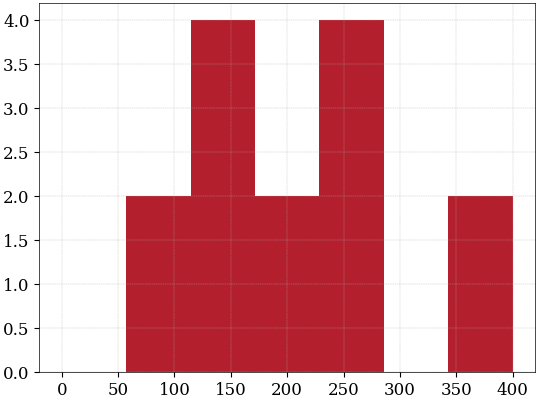

In [417]:
silver_gold = (final['primary_P_Ox'] > 0.8) * (final['primary_z_spec'] > 0)
gold_only = (final['primary_P_Ox'] > 0.9) * (final['primary_z_spec'] > 0)
plt.figure()
plt.hist(final['DM'][silver_gold] - final['DM_NE2001'][silver_gold] - final['DM_YT20'][silver_gold],
        bins = np.linspace(0,400,num = 8))
plt.hist(final['DM'][gold_only] - final['DM_NE2001'][gold_only] - final['DM_YT20'][gold_only],
        bins = np.linspace(0,400,num = 8))

In [271]:
final.sort_index()

,name,ra_frb,dec_frb,b_err,a_err,gal_b,gal_l,DM_YT20,DM_NE2001,theta,...,primary_z_phot_u95,primary_z_spec,secondary_ra,secondary_dec,secondary_P_Ox,secondary_z_phot_median,secondary_z_phot_l95,secondary_z_phot_u95,secondary_z_spec,primary_mag
chime_event_id,,,,,,,,,,,,,,,,,,,,,
254837189,FRB20221209A,297.369563,59.406184,0.000556,0.003586,16.201762,92.061901,43.678359,83.5395,7.033855,...,0.000000,0.000000,297.365916,59.405949,0.162058,0.000000,0.000000,0.000000,0.0,21.524372
268786306,FRB20230203A,151.661594,35.694096,0.000556,0.004994,54.087030,188.712544,29.021503,36.2627,10.148386,...,0.000000,0.000000,151.662766,35.697054,0.029634,0.000000,0.000000,0.000000,0.0,17.921295
272350056,FRB20230222A,106.960358,11.224524,0.000556,0.005935,8.695736,204.716373,35.996640,134.1985,7.575682,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272367619,FRB20230222B,238.739123,30.898695,0.000556,0.003194,49.978718,49.617575,38.416795,27.7330,9.886957,...,0.133350,0.109843,238.737396,30.898905,0.001282,0.493799,0.057626,1.710601,-99.0,17.422754
275629567,FRB20230311A,91.109662,55.945953,0.000556,0.004372,16.039470,157.713374,33.864095,92.4559,9.675111,...,0.000000,0.000000,91.108055,55.946667,0.184785,0.000000,0.000000,0.000000,0.0,19.376910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348537586,FRB20231230A,72.797611,2.393975,0.000556,0.028647,-25.238691,195.870153,30.941726,61.5756,6.567936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348570237,FRB20231230B,355.772818,78.089194,0.000556,0.004585,15.699410,119.320440,38.051108,90.1400,6.537953,...,-1.000000,-1.000000,355.801266,78.094153,0.000389,-1.000000,-1.000000,-1.000000,-1.0,21.248199
348687097,FRB20231231A,342.401870,16.426781,0.000556,0.003158,-37.366519,85.214885,36.801150,41.0328,8.575732,...,0.644146,-99.000000,342.401354,16.427107,0.283960,0.977738,0.730153,1.263284,-99.0,22.179813


# Add HG Redshifts from FFFFPZ

In [376]:
ffffpz = {'FRB20231223C': 0.1059,
'FRB20231206A': 0.0659,
'FRB20231204A': 0.0644,
'FRB20231202A': -2, # too dusty,
'FRB20231201A': -2, # not in FFFFPZ,
'FRB20231128A': 0.1079,
'FRB20231123A': 0.0729,
'FRB20231025B': 0.3238,
'FRB20231025C': -2, # too dusty
'FRB20231017A': 0.2450,
'FRB20231011A': 0.0783,
'FRB20231007B': -2, # too dusty,
'FRB20231005A': 0.0713,
'FRB20230926A': 0.0553,
'FRB20230730A': 0.2115,
'FRB20230703A': 0.1184,
'FRB20230203A': 0.1464
         }

for ind,row in final.iterrows():
    if row['name'] in ffffpz.keys():
        final.at[ind,'primary_z_spec'] = ffffpz[row['name']]


In [426]:
final.keys()

Index(['name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600', 'primary_id',
       'primary_ra', 'primary_dec', 'primary_P_Ox', 'primary_z_phot_median',
       'primary_z_phot_l95', 'primary_z_phot_u95', 'primary_z_spec',
       'secondary_ra', 'secondary_dec', 'secondary_P_Ox',
       'secondary_z_phot_median', 'secondary_z_phot_l95',
       'secondary_z_phot_u95', 'secondary_z_spec', 'primary_mag', 'flux',
       'flux_err', 'fluence', 'fluence_err'],
      dtype='object')

In [377]:
print(final.sort_index()[::-1][['primary_id','name','primary_z_spec','primary_mag']][final.sort_index()[::-1]['primary_P_Ox'] > 0.9].to_string())

                                   primary_id          name  primary_z_spec  primary_mag
chime_event_id                                                                          
347082860             DECaL 10995634357144446  FRB20231223C        0.105900    16.498093
342760050              DECaL 9907738985038273  FRB20231206A        0.065900    16.117691
342256558              DECaL 9907737081938383  FRB20231204A        0.064400    15.397451
341758878       Pan-STARRS 154360650307570235  FRB20231202A       -2.000000    22.745800
341477821       Pan-STARRS 140170545876545920  FRB20231201A       -2.000000    19.429399
339589360              DECaL 9907735753852365  FRB20231128A        0.107900    17.306005
338403209       Pan-STARRS 113360826227259720  FRB20231123A        0.072900    18.294300
330976597              DECaL 9907740469102043  FRB20231025B        0.323800    20.929941
330838705       Pan-STARRS 147880719743595797  FRB20231025C       -2.000000    20.414000
328261629       Pan-S

In [424]:
final.loc[[358105468, 358105468, 339589360, 326456063]]['primary_P_Ox']

chime_event_id
358105468    0.552476
358105468    0.552476
339589360    0.984675
326456063    0.991333
Name: primary_P_Ox, dtype: float64

In [427]:
final[final['primary_P_Ox'] > 0.9]['primary_z_spec']

chime_event_id
325140573    0.071300
342256558    0.064400
339589360    0.107900
347082860    0.105900
330976597    0.323800
330838705   -2.000000
328261629    0.245000
321977347    0.055300
338403209    0.072900
341758878   -2.000000
341477821   -2.000000
326456063    0.078300
300938875    0.118400
306528286    0.211500
268786306    0.146400
272367619    0.109843
342760050    0.065900
325442526   -2.000000
Name: primary_z_spec, dtype: float64

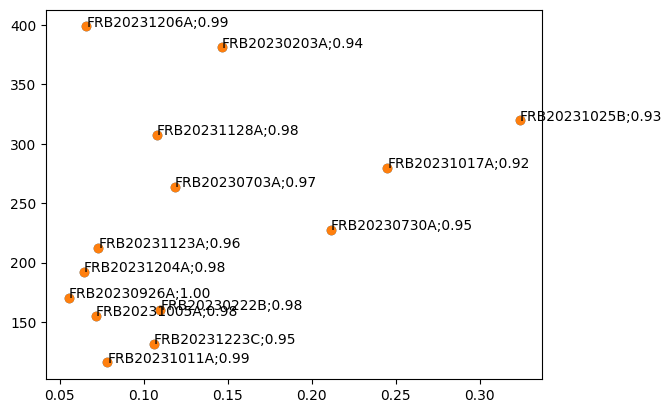

In [305]:
silver_gold = (final['primary_z_spec'] > 0) * (final['primary_P_Ox'] > 0.7)
gold_only = (final['primary_z_spec'] > 0) * (final['primary_P_Ox'] > 0.9)
plt.figure()
plt.scatter(final['primary_z_spec'][silver_gold],final['DM'][silver_gold] - final['DM_NE2001'][silver_gold])
plt.scatter(final['primary_z_spec'][gold_only],final['DM'][gold_only] - final['DM_NE2001'][gold_only])
for ev_id,row in final[gold_only].iterrows():
    plt.text(row['primary_z_spec'],row['DM'] - row['DM_NE2001'],s = f"{row['name']};{row['primary_P_Ox']:.2f}")

In [339]:
decals_fpf = np.load('/arc/home/calvin/kko_host_paper/data_products/fp_vs_bestcand_kko_DECaLs.npz')
panstarrs_fpf = np.load('/arc/home/calvin/kko_host_paper/data_products/fp_vs_bestcand_kko_Pan-STARRS.npz')
"""P_Ox_thresh --> A list of P(O|x) thresholds (the FP fraction is calculated for associations above this threshold)
mag_bin_centers --> A list of the center of each magnitude bin
fp_fraction --> A list of FP fraction of shape: (len(mag_bin_centers), len(P_Ox_thresh))"""

'P_Ox_thresh --> A list of P(O|x) thresholds (the FP fraction is calculated for associations above this threshold)\nmag_bin_centers --> A list of the center of each magnitude bin\nfp_fraction --> A list of FP fraction of shape: (len(mag_bin_centers), len(P_Ox_thresh))'

In [340]:
decals_fpf['P_Ox_thresh'],panstarrs_fpf['P_Ox_thresh']

(array([0. , 0.6, 0.8, 0.9]), array([0. , 0.6, 0.8, 0.9]))

In [368]:
plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')

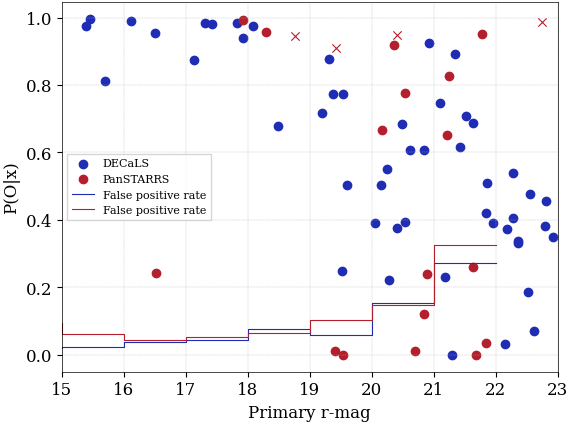

In [383]:
plt.figure()
in_dec = np.array(['DEC' in str(f) for f in final['primary_id']]) * (final['primary_z_spec'] != -2)
in_pan = np.array(['Pan' in str(f) for f in final['primary_id']]) * (final['primary_z_spec'] != -2)
in_dec_dusty = np.array(['DEC' in str(f) for f in final['primary_id']]) * (final['primary_z_spec'] == -2)
in_pan_dusty = np.array(['Pan' in str(f) for f in final['primary_id']]) * (final['primary_z_spec'] == -2)
plt.scatter(final['primary_mag'][in_dec],final['primary_P_Ox'][in_dec],label = 'DECaLS')
plt.scatter(final['primary_mag'][in_pan],final['primary_P_Ox'][in_pan],label = 'PanSTARRS')
plt.scatter(final['primary_mag'][in_dec_dusty],final['primary_P_Ox'][in_dec_dusty],label = 'Too dusty',marker = 'x',color = 'C0')
plt.scatter(final['primary_mag'][in_pan_dusty],final['primary_P_Ox'][in_pan_dusty],label = 'Too dusty',marker = 'x',color = 'C1')

plt.step(decals_fpf['mag_bin_centers'],decals_fpf['fp_fraction'][:,-1],color = 'C0',label = 'False positive rate')
plt.step(panstarrs_fpf['mag_bin_centers'],panstarrs_fpf['fp_fraction'][:,-1],color = 'C1',label = 'False positive rate')
plt.xlim(15,23)
#plt.ylim(0.9,1.0)
plt.legend(loc='center left')
#for ev_id,row in final.iterrows():
#    plt.text(row['primary_mag'],row['primary_P_Ox'],s = f"{ev_id}")
plt.xlabel('Primary r-mag')
plt.ylabel('P(O|x)')
plt.show()
plt.savefig('/arc/home/calvin/kko_host_paper/

In [6]:
import numpy as np

In [7]:
%pdb on

Automatic pdb calling has been turned ON


In [15]:
hgra = []
hgdec = []
hg_gmag = []
hg_gmag_err = []
hg_rmag = []
hg_rmag_err = []
hg_zmag = []
hg_zmag_err = []

for event_id,burst in csv.iterrows():
    if type(burst['hg_id']) is not float:
        surv, survey_id = burst['hg_id'].split(' ')
        sc = coord.SkyCoord(ra = burst['ra'],dec = burst['dec'], unit="deg")
        radius = 3*u.arcmin
        if surv == 'Pan-STARRS':
            survey = Pan_STARRS_Survey(sc, radius)
            catalog = survey.get_catalog()
            catalog = catalog[catalog['Pan-STARRS_ID']==survey_id]
            hg_gmag.append(catalog['Pan-STARRS_g'])
            hg_rmag.append(catalog['Pan-STARRS_r'])
            hg_zmag.append(catalog['Pan-STARRS_z'])
            hg_gmag_err.append(catalog['Pan-STARRS_g_err'])
            hg_rmag_err.append(catalog['Pan-STARRS_r_err'])
            hg_zmag_err.append(catalog['Pan-STARRS_z_err'])
        elif surv == 'DECaL':
            survey = DECaL_Survey(sc, radius)
            catalog = survey.get_catalog()
            catalog = catalog[catalog['DECaL_ID']==survey_id]
            hg_gmag.append(catalog['DECaL_g'])
            hg_gmag_err.append(catalog['DECaL_g_err'])
            hg_rmag.append(catalog['DECaL_r'])
            hg_rmag_err.append(catalog['DECaL_r_err'])
            hg_zmag.append(catalog['DECaL_z'])
            hg_zmag_err.append(catalog['DECaL_z_err'])
        print(catalog)
        hgra.append(catalog['ra'])
        hgdec.append(catalog['dec'])

    else:
        hgra.append(np.nan)
        hgdec.append(np.nan)
        hg_gmag.append(np.nan)
        hg_rmag.append(np.nan)
        hg_zmag.append(np.nan)
        hg_gmag_err.append(np.nan)
        hg_rmag_err.append(np.nan)
        hg_zmag_err.append(np.nan)


/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID        ra         dec     objInfoFlag qualityFlag      rKronRad           gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr          rPSFmagErr          iPSFmagErr          zPSFmagErr          yPSFmagErr     Pan-STARRS_g    Pan-STARRS_r       Pan-STARRS_i       Pan-STARRS_z   Pan-STARRS_y Pan-STARRS_g_err   Pan-STARRS_r_err    Pan-STARRS_i_err    Pan-STARRS_z_err  Pan-STARRS_y_err      separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                               arcmin      
------------------ ---------- ----------- ------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra          dec     objInfoFlag qualityFlag      rKronRad           gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr            rPSFmagErr           iPSFmagErr           zPSFmagErr           yPSFmagErr        Pan-STARRS_g       Pan-STARRS_r    Pan-STARRS_i Pan-STARRS_z    Pan-STARRS_y      Pan-STARRS_g_err     Pan-STARRS_r_err   Pan-STARRS_i_err Pan-STARRS_z_err   Pan-STARRS_y_err        separation     
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          arcmin       
------------------ -----

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


...

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra        dec     objInfoFlag qualityFlag rKronRad      gPSFmag           rPSFmag           iPSFmag           zPSFmag            yPSFmag          gPSFmagErr         rPSFmagErr          iPSFmagErr         zPSFmagErr          yPSFmagErr     Pan-STARRS_g Pan-STARRS_r    Pan-STARRS_i      Pan-STARRS_z   Pan-STARRS_y Pan-STARRS_g_err Pan-STARRS_r_err   Pan-STARRS_i_err   Pan-STARRS_z_err  Pan-STARRS_y_err      separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                   arcmin      
------------------ ----------- ---------- ----------- ----------- -------- ------------------ ----------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


  Pan-STARRS_ID         ra         dec     objInfoFlag qualityFlag      rKronRad          gPSFmag            rPSFmag            iPSFmag            zPSFmag            yPSFmag            gPSFmagErr          rPSFmagErr          iPSFmagErr           zPSFmagErr           yPSFmagErr     Pan-STARRS_g    Pan-STARRS_r       Pan-STARRS_i       Pan-STARRS_z       Pan-STARRS_y    Pan-STARRS_g_err   Pan-STARRS_r_err    Pan-STARRS_i_err    Pan-STARRS_z_err   Pan-STARRS_y_err       separation    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          arcmin      
------------------ -------

/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/table/column.py:347: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = getattr(super(Column, self), op)(other)


In [ ]:
csv = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv',
    columns = ['name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600', 'primary_id',
       'primary_ra', 'primary_dec', 'primary_P_Ox', 'primary_z_phot_median',
       'primary_z_phot_l95', 'primary_z_phot_u95', 'primary_z_spec',
       'secondary_ra', 'secondary_dec', 'secondary_P_Ox',
       'secondary_z_phot_median', 'secondary_z_phot_l95',
       'secondary_z_phot_u95', 'secondary_z_spec', 'primary_mag', 'flux',
       'flux_err', 'fluence', 'fluence_err']
                 )

In [17]:
csv = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')
csv.set_index('chime_event_id',inplace=True)
csv.insert(loc = 5, column = 'hg_primary_ra', value = np.array(hgra))
csv.insert(loc = 6, column = 'hg_primary_dec', value = np.array(hgdec))
csv.insert(loc = 6, column = 'hg_primary_g', value = np.array(hg_gmag))
csv.insert(loc = 6, column = 'hg_primary_g_err', value = np.array(hg_gmag_err))
csv.insert(loc = 6, column = 'hg_primary_r', value = np.array(hg_rmag))
csv.insert(loc = 6, column = 'hg_primary_r_err', value = np.array(hg_rmag_err))
csv.insert(loc = 6, column = 'hg_primary_z', value = np.array(hg_zmag))
csv.insert(loc = 6, column = 'hg_primary_z_err', value = np.array(hg_zmag_err))

In [21]:
csv.to_csv('/arc/home/calvin/kko_host_paper/data_products/KKO_bursts_full.csv')


In [ ]:
pdf = pd.read_csv('/arc/home/calvin/FRB/frb/data/Galaxies/PDF_Mr.csv')

plt.figure()
plt.plot(pdf['Mr'],pdf['PDF'])
cdf = np.cumsum(pdf['PDF'].values)
cdf /= cdf[-1]
plot_cdf = (1 - cdf) * 0.023
plt.plot(pdf['Mr'],plot_cdf,label = 'CDF')
fainter_than_121102 = pdf['Mr'] > -17
plt.fill_between(pdf['Mr'][fainter_than_121102],
                 0,pdf['PDF'][fainter_than_121102],
                 label = "M_R' of 121102: 4% of hosts observed so far",alpha = 0.2)
plt.legend()
plt.xlabel(f'M_R (left is more luminous)')
print(cdf[np.argmin(np.abs(pdf['Mr'] - -17))])

import numpy as np
a = np.load('/arc/home/calvin/CHIMEFRB-Cat1-Energy-Dist-Distrs/data/P_obs(z|DM).npz')

z = a['z']
dm = a['dm'] # Kaitlyn says DM_MW = 80
P_obs_z_givenDM = a['P_obs_z_givenDM']

import matplotlib.pyplot as plt
plt.figure(figsize = (15,10))
np.min(np.log10(P_obs_z_givenDM))
plt.style.use('/arc/home/calvin/vlbi-correlator-localization/plot_scripts/paper_sty.mplstyle')
plt.contourf(z[:-1],dm,P_obs_z_givenDM[:,:-1] * 1,cmap = 'viridis',levels = 40)
for pox_min in [0.6,0.8,0.9,0.95]:
    which = final['P_Ox'] > pox_min
    plt.scatter(final['redshift'][which],final['DM'][which] - final['DM_NE2001'][which],label = f'$P(O|x) > {pox_min:.2f}$')
plt.xlim(0,0.9)
plt.ylim(29,1000)
#plt.scatter(final['Redshift'],final['DM'],color = 'white')
plt.ylabel('Extragalactic DM [pc cm$^{-3}$]',fontsize = 13)
plt.xlabel('Redshift',fontsize = 13)
cbar = plt.colorbar()
cbar.set_label('P(z $\mid$ DM)', rotation=270, labelpad=20,fontsize = 13)
plt.plot(np.array([0,0.7,1]),np.array([0,718,718 / 0.7]),color = 'black',label = 'Macquart 2020')
plt.legend()
plt.grid(False)